Shape:
(200, 9)

Columns:
Index(['Intern_ID', 'Age', 'Major', 'Internship_Duration_Months', 'Department',
       'Supervisor_Evaluation', 'Salary', 'Attendance_%', 'Retained'],
      dtype='str')

Info:
<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 9 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Intern_ID                   200 non-null    int64  
 1   Age                         200 non-null    int64  
 2   Major                       200 non-null    str    
 3   Internship_Duration_Months  200 non-null    int64  
 4   Department                  200 non-null    str    
 5   Supervisor_Evaluation       200 non-null    float64
 6   Salary                      200 non-null    int64  
 7   Attendance_%                200 non-null    float64
 8   Retained                    200 non-null    int64  
dtypes: float64(2), int64(5), str(2)
memory usage: 14.2 KB
None

Null values:

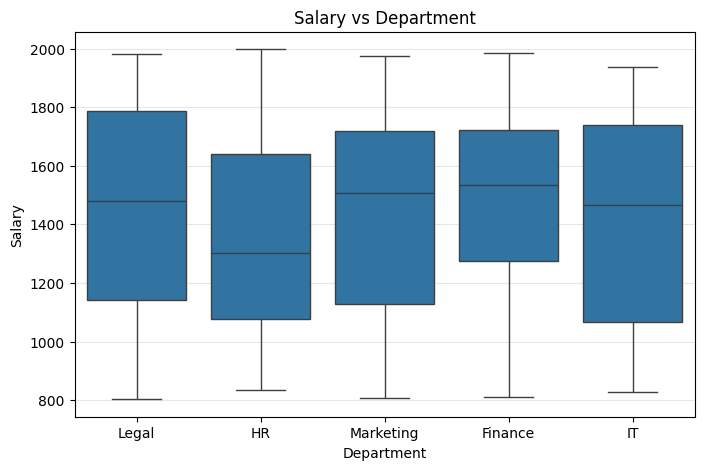


Cleaned file saved as: intern_retention_clean.csv


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


# 1. Load data
def load_data(path):
    df = pd.read_csv(path)
    return df


# 2. Basic overview
def basic_info(df):
    print("Shape:")
    print(df.shape)

    print("\nColumns:")
    print(df.columns)

    print("\nInfo:")
    print(df.info())

    print("\nNull values:")
    print(df.isna().sum())

    print("\nDuplicates:")
    print(df.duplicated().sum())

    print("\nDescribe:")
    print(df.describe())


# 3. Basic cleaning
def clean_data(df, list_to_drop=None):
    df = df.drop_duplicates()
    if list_to_drop:
        df = df.drop(columns=list_to_drop, errors="ignore")
    return df


# 4. Specific columns creation (limited to this dataset)
def create_columns(df):
    if "Salary" in df.columns and "Attendance_%" in df.columns:
        df["Salary_Attendance_ratio"] = (df["Salary"] / df["Attendance_%"]).round(2)

    if "Supervisor_Evaluation" in df.columns:
        df["Evaluation_Flag"] = df["Supervisor_Evaluation"] >= 2.5

    if "Salary" in df.columns:
        df["Salary_Rate"] = df["Salary"].apply(
            lambda x: "Low" if x < 1000
            else "Above average" if x < 1424
            else "Average" if x < 1736
            else "High Salary"
        )

    return df


# 5. Simple EDA plots
def count_plot(df, col1, col2):
    if col1 in df.columns and col2 in df.columns:
        plt.figure(figsize=(8, 5))
        sns.countplot(data=df, x=col1, hue=col2)
        plt.title(f"Retention by {col1}")
        plt.show()
    else:
        pass


def box_plot(df, col1, col2):
    if col1 in df.columns and col2 in df.columns:
        plt.figure(figsize=(8, 5))
        sns.boxplot(data=df, x=col1, y=col2)
        plt.title(f"{col2} vs {col1}")
        plt.grid(axis="y", alpha=0.3)
        plt.show()
    else:
        pass


def violin_plot(df, col1, col2):
    if col1 in df.columns and col2 in df.columns:
        plt.figure(figsize=(8, 5))
        sns.violinplot(data=df, x=col1, y=col2)
        plt.title(f"{col2} vs {col1}")
        plt.grid(axis="y", alpha=0.3)
        plt.show()
    else:
        pass


# 6. Save cleaned file
def save_data(df, output_name):
    df.to_csv(output_name, index=False)
    print(f"\nCleaned file saved as: {output_name}")


# 7. Main automation
def main():
    path = r"C:\Users\s3rgi\OneDrive\Área de Trabalho\intern-retention-project\Project\data\processed\HR-Intern-Retention_processed.csv"

    df = load_data(path)
    basic_info(df)

    df = clean_data(df)
    df = create_columns(df)
    charts = input("Do you want to create charts (yes/no): ").strip().lower()

    if charts == "yes":
        while True:
            print("\nAvailable columns:")
            print(list(df.columns))

            chart_type = input("Select chart (count/box/violin): ").strip().lower()
            col1 = input("Select first column: ").strip()
            col2 = input("Select second column: ").strip()

            if col1 not in df.columns or col2 not in df.columns:
                print("Invalid columns. Try again.")
                continue

            if chart_type == "count":
                count_plot(df, col1, col2)
            elif chart_type == "box":
                box_plot(df, col1, col2)
            elif chart_type == "violin":
                violin_plot(df, col1, col2)
            else:
                print("Invalid chart type.")
                continue

            again = input("\nDo you want to create another chart? (yes/no): ").strip().lower()

            if again != "yes":
                break

    else:
        print("Charts skipped.")
    
    save_data(df, "intern_retention_clean.csv")


# Run everything
main()